In [ ]:
# hdfs_analysis.py
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from Pipe import PipeDF
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    array_contains,
    array_join,
    avg,
    col,
    count,
    desc,
    explode,
    expr,
    hour,
    lit,
    max,
    min,
    minute,
)
from pyspark.sql.functions import sum as spark_sum
from pyspark.sql.functions import when

# Initialize Spark session with the same configuration as in main.py
spark = (
    SparkSession.builder.appName("HDFS Log Analysis")
    .config(
        "spark.sql.shuffle.partitions", "32"
    )  # Using optimal partition count from benchmark
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)


# Define the array_to_string UDF globally to avoid registration errors
def array_to_string(arr):
    if arr is None:
        return None
    return ",".join(arr)


# Register the UDF properly
array_to_string_udf = spark.udf.register("array_to_string", array_to_string)


class LogAnalyzer:
    def __init__(self, pipe_df=None, data_dir="data/"):
        """Initialize the log analyzer with a PipeDF object or data directory."""
        if pipe_df is not None:
            self.pipe_df = pipe_df
            self.parsed_df = pipe_df.parsed_df
            self.blocks_df = pipe_df.blocks_df
        else:
            self.pipe_df = PipeDF(spark, data_dir)
            self.pipe_df.pipeline()  # Run the pipeline to get parsed_df and blocks_df
            self.parsed_df = self.pipe_df.parsed_df
            self.blocks_df = self.pipe_df.blocks_df

        self.results = {}  # Store analysis results

    def analyze_error_frequencies(self):
        """
        Analyze error frequencies by component.
        Which components generate the most errors or warnings?
        """
        print("Analyzing error frequencies by component...")

        # Filter for ERROR and WARNING log levels
        error_warning_df = self.parsed_df.filter(
            (col("level") == "ERROR") | (col("level") == "WARN")
        )

        # Group by component and level, count occurrences
        component_errors = (
            error_warning_df.groupBy("component", "level")
            .count()
            .orderBy(desc("count"))
        )

        # Cache for faster repeated access
        component_errors.cache()

        # Show top components with errors/warnings
        print("Top components with errors or warnings:")
        component_errors.show(10)

        # Save results
        self.results["error_frequencies"] = component_errors

        # Create visualization
        plt.figure(figsize=(12, 6))

        # Convert to pandas for easier plotting
        pdf = component_errors.toPandas()

        # Plot grouped bar chart
        chart = sns.barplot(x="component", y="count", hue="level", data=pdf)
        chart.set_xticklabels(chart.get_xticklabels(), rotation=45, ha="right")
        plt.title("Error and Warning Counts by Component")
        plt.tight_layout()
        plt.savefig("error_frequencies.png", dpi=300)
        plt.show()

        return component_errors

    def analyze_peak_activity_times(self):
        """
        Analyze peak times for system activity.
        What are the peak times for system activity?
        """
        print("Analyzing peak activity times...")

        # Extract hour from timestamp
        hourly_activity = (
            self.parsed_df.withColumn("hour", hour("timestamp"))
            .groupBy("hour")
            .count()
            .orderBy("hour")
        )

        # Show hourly activity
        print("Hourly activity distribution:")
        hourly_activity.show()

        # Save results
        self.results["peak_activity_times"] = hourly_activity

        # Create visualization
        plt.figure(figsize=(12, 6))

        # Convert to pandas for easier plotting
        pdf = hourly_activity.toPandas()

        # Plot line chart
        plt.plot(pdf["hour"], pdf["count"], marker="o", linestyle="-")
        plt.xlabel("Hour of Day")
        plt.ylabel("Number of Log Events")
        plt.title("System Activity by Hour")
        plt.xticks(range(0, 24))
        plt.grid(True, alpha=0.3)
        plt.savefig("peak_activity_times.png", dpi=300)
        plt.show()

        return hourly_activity

    def analyze_failure_patterns(self):
        """
        Analyze patterns preceding system failures or anomalies.
        Are there patterns preceding system failures or performance degradation?
        """
        print("Analyzing patterns preceding failures...")

        # Filter blocks with anomalies (Label = 1)
        anomaly_blocks = self.blocks_df.filter(col("Label") == 1)
        normal_blocks = self.blocks_df.filter(col("Label") == 0)

        # Count anomalies
        anomaly_count = anomaly_blocks.count()
        normal_count = normal_blocks.count()
        total_count = anomaly_count + normal_count

        print(f"Total blocks: {total_count}")
        print(f"Normal blocks: {normal_count} ({normal_count/total_count*100:.2f}%)")
        print(f"Anomaly blocks: {anomaly_count} ({anomaly_count/total_count*100:.2f}%)")

        # Use array_join function instead of UDF to avoid errors
        anomaly_events = (
            anomaly_blocks.withColumn("event_sequence", array_join(col("events"), ","))
            .groupBy("event_sequence")
            .count()
            .orderBy(desc("count"))
        )

        print("Most common event sequences in anomalies:")
        anomaly_events.show(5, truncate=False)

        # Compare component distribution in anomalies vs normal
        anomaly_components = (
            anomaly_blocks.select(explode(col("components")).alias("component"))
            .groupBy("component")
            .count()
            .withColumn("type", lit("anomaly"))
        )

        normal_components = (
            normal_blocks.select(explode(col("components")).alias("component"))
            .groupBy("component")
            .count()
            .withColumn("type", lit("normal"))
        )

        component_comparison = anomaly_components.union(normal_components)

        # Save results
        self.results["failure_patterns"] = {
            "anomaly_events": anomaly_events,
            "component_comparison": component_comparison,
        }

        # Create visualization - Component comparison
        plt.figure(figsize=(12, 8))

        # Convert to pandas for easier plotting
        pdf = component_comparison.toPandas()

        # Normalize counts as percentages within each type
        for t in pdf["type"].unique():
            type_total = pdf[pdf["type"] == t]["count"].sum()
            pdf.loc[pdf["type"] == t, "percentage"] = (
                pdf[pdf["type"] == t]["count"] / type_total * 100
            )

        # Plot component distribution comparison
        sns.barplot(x="component", y="percentage", hue="type", data=pdf)
        plt.title("Component Distribution: Anomaly vs Normal Blocks")
        plt.xlabel("Component")
        plt.ylabel("Percentage within Type")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("component_anomaly_comparison.png", dpi=300)
        plt.show()

        return anomaly_events

    def analyze_log_level_distribution(self):
        """
        Analyze log level distribution across components.
        How does log level distribution vary across different components?
        """
        print("Analyzing log level distribution across components...")

        # Group by component and level
        level_distribution = (
            self.parsed_df.groupBy("component", "level")
            .count()
            .orderBy("component", "level")
        )

        # Calculate percentage within each component
        window_spec = Window.partitionBy("component")
        level_distribution = level_distribution.withColumn(
            "total", spark_sum("count").over(window_spec)
        ).withColumn("percentage", (col("count") / col("total") * 100))

        # Show distribution
        print("Log level distribution by component:")
        level_distribution.orderBy("component", desc("count")).show(20)

        # Save results
        self.results["log_level_distribution"] = level_distribution

        # Create visualization
        # Find top N components by log count for clearer visualization
        top_components = (
            self.parsed_df.groupBy("component")
            .count()
            .orderBy(desc("count"))
            .limit(10)
            .select("component")
            .rdd.flatMap(lambda x: x)
            .collect()
        )

        # Filter for top components
        top_level_distribution = level_distribution.filter(
            col("component").isin(top_components)
        )

        plt.figure(figsize=(14, 8))

        # Convert to pandas for easier plotting
        pdf = top_level_distribution.toPandas()

        # Create a stacked percentage bar chart
        chart = sns.barplot(x="component", y="percentage", hue="level", data=pdf)
        chart.set_xticklabels(chart.get_xticklabels(), rotation=45, ha="right")
        plt.title("Log Level Distribution by Component")
        plt.ylabel("Percentage")
        plt.tight_layout()
        plt.savefig("log_level_distribution.png", dpi=300)
        plt.show()

        return level_distribution

    def analyze_performance_metrics(self):
        """
        Analyze performance metrics like processing time and latency.
        What are the performance characteristics of different components?
        """
        print("Analyzing performance metrics...")

        # Analyze block latency distribution
        latency_stats = self.blocks_df.select(
            min("latency").alias("min_latency"),
            max("latency").alias("max_latency"),
            avg("latency").alias("avg_latency"),
            expr("percentile(latency, 0.5)").alias("median_latency"),
            expr("percentile(latency, 0.95)").alias("p95_latency"),
        )

        print("Block latency statistics (seconds):")
        latency_stats.show()

        # Analyze latency by component involvement
        # For each unique component, find average latency of blocks containing it
        unique_components = (
            self.parsed_df.select("component")
            .distinct()
            .rdd.flatMap(lambda x: x)
            .collect()
        )

        component_latency_data = []
        for comp in unique_components:
            # Use array_contains to check if component is in the components array
            filtered_blocks = self.blocks_df.filter(
                array_contains(col("components"), comp)
            )

            # Only proceed if there are matching blocks
            if filtered_blocks.count() > 0:
                avg_lat = filtered_blocks.select(
                    avg("latency").alias("avg_latency")
                ).collect()[0]["avg_latency"]
                component_latency_data.append(
                    (comp, avg_lat if avg_lat is not None else 0)
                )

        component_latency_df = spark.createDataFrame(
            component_latency_data, ["component", "avg_latency"]
        ).orderBy(desc("avg_latency"))

        print("Average latency by component involvement:")
        component_latency_df.show(10)

        # Save results
        self.results["performance_metrics"] = {
            "latency_stats": latency_stats,
            "component_latency": component_latency_df,
        }

        # Create visualization
        plt.figure(figsize=(12, 6))

        # Convert to pandas for easier plotting
        pdf = component_latency_df.toPandas()

        # Sort by average latency for better visualization
        pdf = pdf.sort_values("avg_latency", ascending=False).head(15)

        sns.barplot(x="component", y="avg_latency", data=pdf)
        plt.title("Average Block Latency by Component Involvement")
        plt.ylabel("Average Latency (seconds)")
        plt.xlabel("Component")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("component_latency.png", dpi=300)
        plt.show()

        return component_latency_df

    def run_all_analyses(self):
        """Run all analysis methods and save results."""
        analyses = [
            self.analyze_error_frequencies,
            self.analyze_peak_activity_times,
            self.analyze_failure_patterns,
            self.analyze_log_level_distribution,
            self.analyze_performance_metrics,
        ]

        for analysis in analyses:
            analysis()

        print("All analyses completed. Results saved.")
        return self.results

In [ ]:
df_pipe = PipeDF(spark=spark)
df_pipe.pipeline()


STEP 1: Loading Data
+----------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                     |
+----------------------------------------------------------------------------------------------------------------------------------------------------------+
|081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010            |
|081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906|
|081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010                |
+-----------------------------------

+-------------+---+-----+----------------------------+------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------+-------+-------------------+
|date_time    |pid|level|component                   |BlockId                 |value                                                                                                                                                     |EventId|timestamp          |
+-------------+---+-----+----------------------------+------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------+-------+-------------------+
|081109 203518|143|INFO |dfs.DataNode$DataXceiver    |blk_-1608999687919862906|081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19

+--------------------+--------------------+--------------------+-------+--------------------+--------------------+--------------------+-----+
|             BlockId|              events|           intervals|latency|              levels|          components|                pids|Label|
+--------------------+--------------------+--------------------+-------+--------------------+--------------------+--------------------+-----+
|blk_-100029794687...|[E5, E5, E5, E22,...|[0, 0, 0, 0, 35, ...|  22135|[INFO, INFO, INFO...|[dfs.DataNode$Dat...|[12536, 12617, 12...|    0|
|blk_-100032145436...|[E5, E5, E5, E22,...|[0, 0, 0, 0, 29, ...|  23355|[INFO, INFO, INFO...|[dfs.DataNode$Dat...|[12401, 12422, 12...|    0|
|blk_-100080480388...|[E5, E5, E22, E5,...|[0, 0, 0, 1, 47, ...|   1540|[INFO, INFO, INFO...|[dfs.DataNode$Dat...|[21852, 21961, 34...|    0|
|blk_-100105235745...|[E5, E22, E5, E5,...|[0, 0, 1, 0, 39, ...|  47976|[INFO, INFO, INFO...|[dfs.DataNode$Dat...|[1701, 30, 1697, ...|    0|
|blk_-

Analyzing error frequencies by component...
Top components with errors or warnings:


/var/folders/lj/0wwrvd593fs6m_bwwbmvddy40000gp/T/ipykernel_65144/356624891.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, ha="right")


+--------------------+-----+------+
|           component|level| count|
+--------------------+-----+------+
|dfs.DataNode$Data...| WARN|356207|
|       dfs.FSDataset| WARN|  5545|
|    dfs.FSNamesystem| WARN|   975|
|dfs.PendingReplic...| WARN|    47|
|dfs.DataBlockScanner| WARN|    10|
|dfs.DataNode$Data...| WARN|     9|
+--------------------+-----+------+



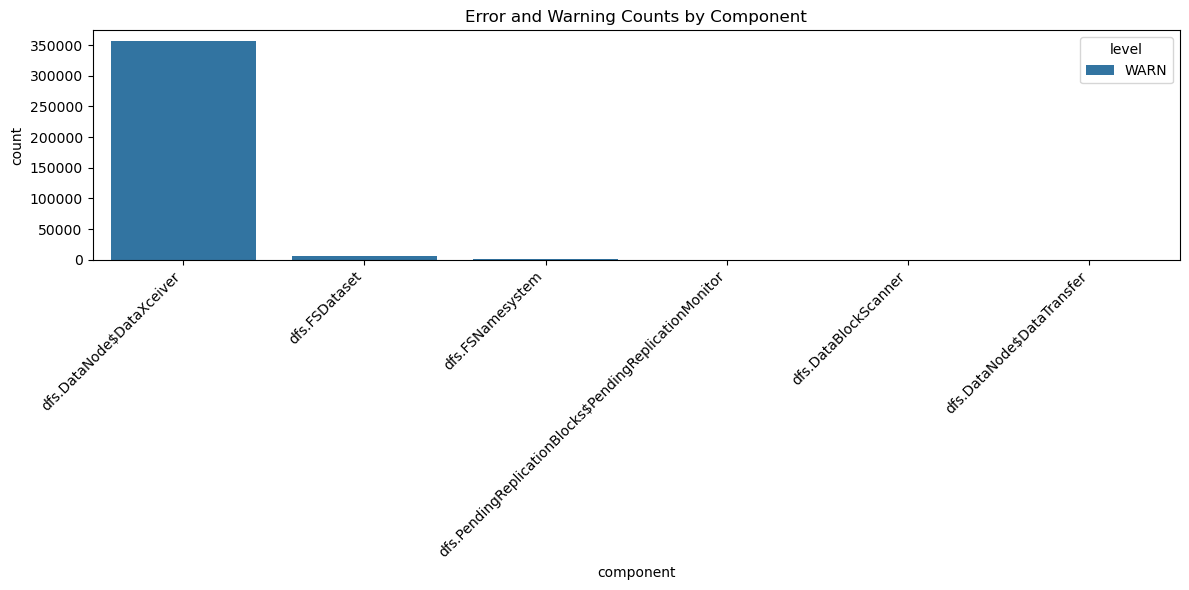

Analyzing peak activity times...
Hourly activity distribution:


+----+-------+
|hour|  count|
+----+-------+
|   0| 202260|
|   1| 461017|
|   2| 478238|
|   3| 486535|
|   4| 870909|
|   5| 495709|
|   6| 673961|
|   7| 753331|
|   8| 677613|
|   9| 623958|
|  10|1279472|
|  11| 690667|
|  12| 340106|
|  13|  93782|
|  14| 255394|
|  15| 181779|
|  16|  24469|
|  17|  27506|
|  18|  27078|
|  19|  26716|
+----+-------+
only showing top 20 rows



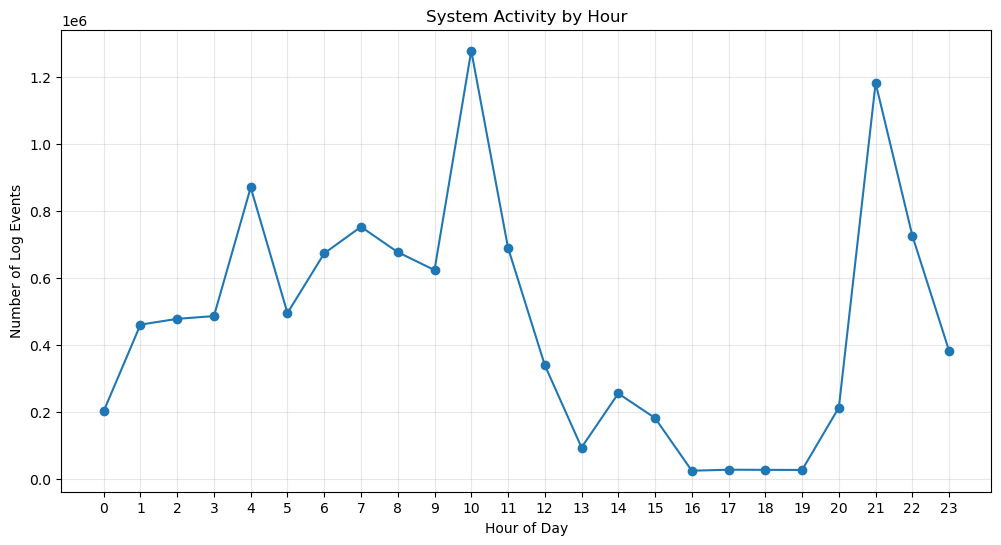

Analyzing patterns preceding failures...


Total blocks: 575061
Normal blocks: 558223 (97.07%)
Anomaly blocks: 16838 (2.93%)
Most common event sequences in anomalies:


+--------------+-----+
|event_sequence|count|
+--------------+-----+
|E5,E22        |1643 |
|E22,E5,E5,E7  |1361 |
|E22,E5        |1307 |
|E5,E5,E22,E7  |1252 |
|E5,E22,E5,E7  |612  |
+--------------+-----+
only showing top 5 rows



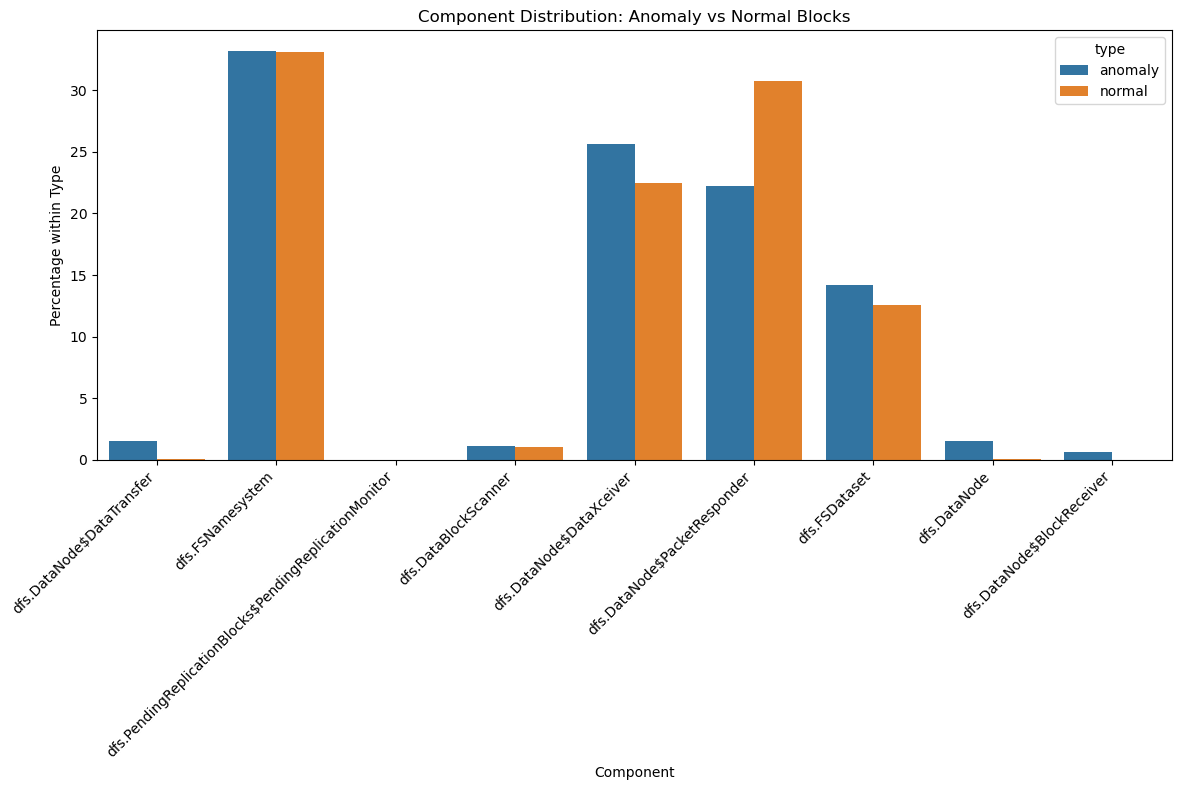

Analyzing log level distribution across components...
Log level distribution by component:


+--------------------+-----+-------+-------+--------------------+
|           component|level|  count|  total|          percentage|
+--------------------+-----+-------+-------+--------------------+
|dfs.DataBlockScanner| INFO| 120036| 120046|   99.99166985988704|
|dfs.DataBlockScanner| WARN|     10| 120046|0.008330140112956701|
|        dfs.DataNode| INFO|   7002|   7002|               100.0|
|dfs.DataNode$Bloc...| INFO|   1718|   1718|               100.0|
|dfs.DataNode$Data...| INFO|   6937|   6946|   99.87042902389864|
|dfs.DataNode$Data...| WARN|      9|   6946|  0.1295709761013533|
|dfs.DataNode$Data...| INFO|2162471|2518678|   85.85738232517217|
|dfs.DataNode$Data...| WARN| 356207|2518678|  14.142617674827825|
|dfs.DataNode$Pack...| INFO|3413350|3413350|               100.0|
|       dfs.FSDataset| INFO|1402052|1407597|   99.60606622492091|
|       dfs.FSDataset| WARN|   5545|1407597|  0.3939337750790887|
|    dfs.FSNamesystem| INFO|3699270|3700245|    99.9736503934199|
|    dfs.F

/var/folders/lj/0wwrvd593fs6m_bwwbmvddy40000gp/T/ipykernel_65144/356624891.py:282: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, ha="right")


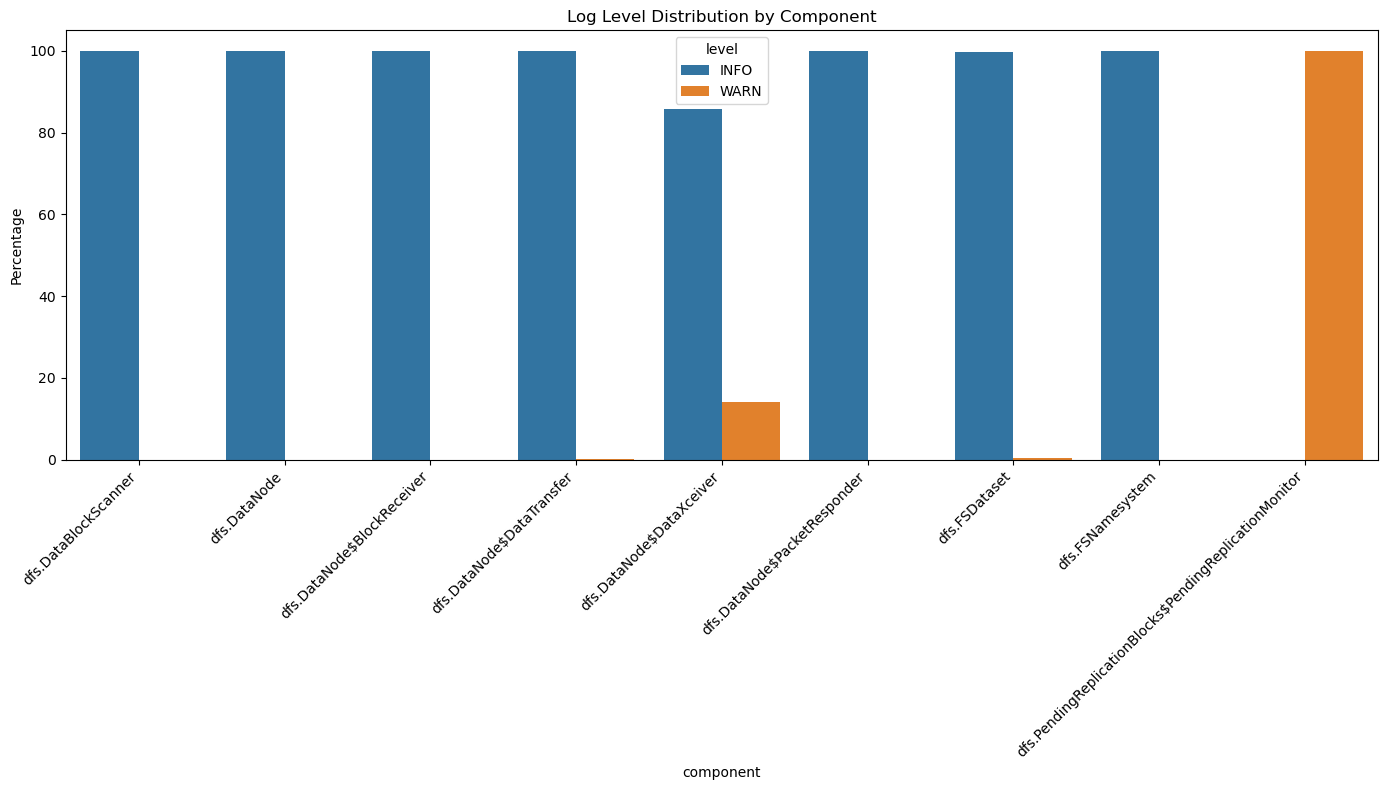

Analyzing performance metrics...
Block latency statistics (seconds):


+-----------+-----------+------------------+--------------+-----------+
|min_latency|max_latency|       avg_latency|median_latency|p95_latency|
+-----------+-----------+------------------+--------------+-----------+
|          0|      54025|16789.470527474477|        7229.0|    50815.0|
+-----------+-----------+------------------+--------------+-----------+



Average latency by component involvement:
+--------------------+------------------+
|           component|       avg_latency|
+--------------------+------------------+
|dfs.DataBlockScanner| 36854.78815137227|
|dfs.PendingReplic...|22816.847826086956|
|       dfs.FSDataset|20562.458442891522|
|dfs.DataNode$Data...|20039.712435726527|
|        dfs.DataNode| 20009.75811041548|
|dfs.DataNode$Pack...|16971.867381521588|
|    dfs.FSNamesystem|16789.470527474477|
|dfs.DataNode$Data...|16789.470527474477|
|dfs.DataNode$Bloc...|  11904.0990990991|
+--------------------+------------------+



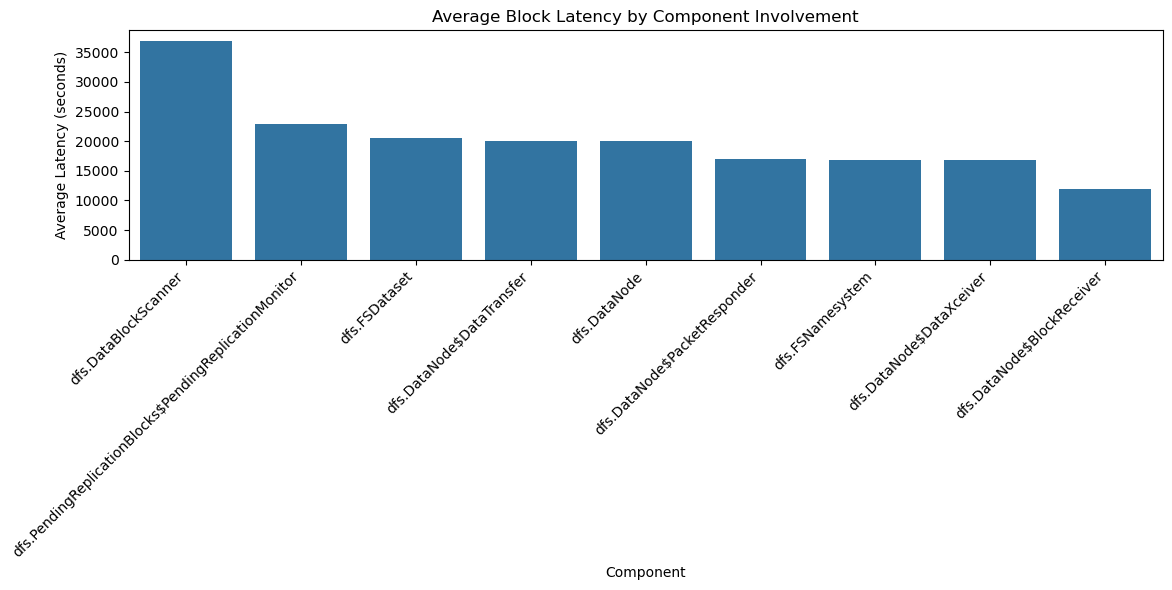

All analyses completed. Results saved.


In [ ]:
# Create analyzer with existing PipeDF
analyzer = LogAnalyzer(pipe_df=df_pipe)

# Run all analyses
results = analyzer.run_all_analyses()

ANALYSIS OF HDFS LOG DATA RESULTS

1. COMPONENTS GENERATING THE MOST ERRORS/WARNINGS:
Top components by error/warning count:


,component,level,count
0,dfs.DataNode$DataXceiver,WARN,356207
1,dfs.FSDataset,WARN,5545
2,dfs.FSNamesystem,WARN,975
3,dfs.PendingReplicationBlocks$PendingReplicatio...,WARN,47
4,dfs.DataBlockScanner,WARN,10
5,dfs.DataNode$DataTransfer,WARN,9


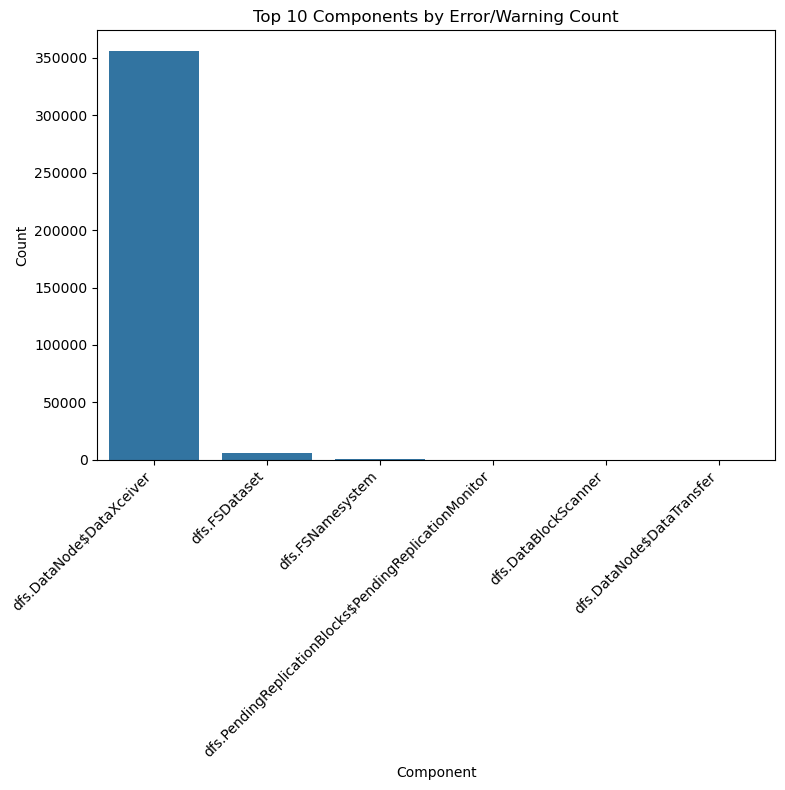

Key Finding: The component 'dfs.DataNode$DataXceiver' generates the most errors/warnings, with 356207 occurrences.

2. PEAK TIMES FOR SYSTEM ACTIVITY:
Top 3 peak hours for system activity:


,hour,count
10,10,1279472
21,21,1182898
4,4,870909


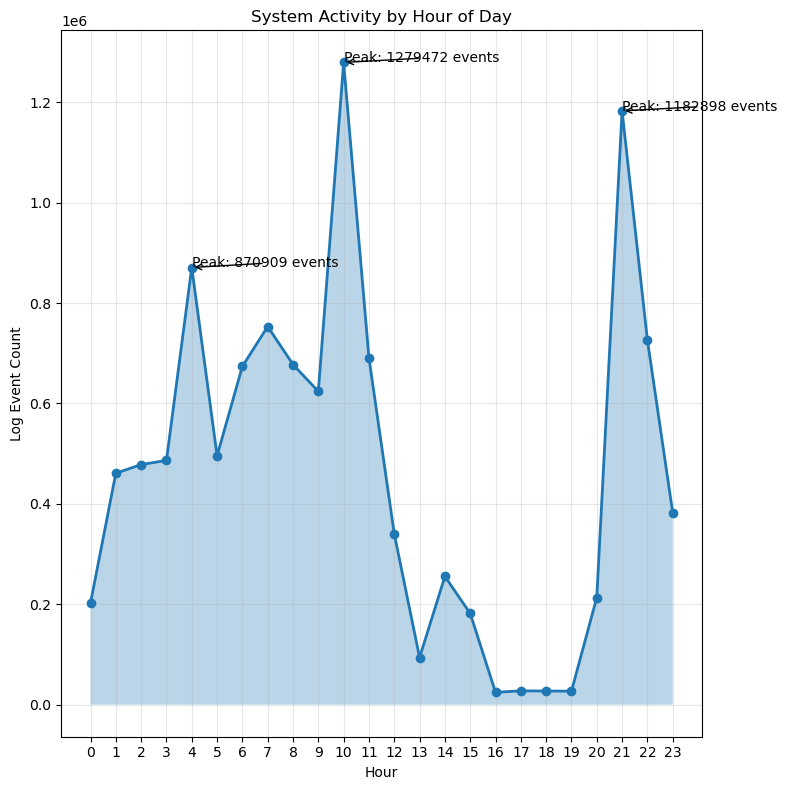

Key Finding: The system experiences peak activity at hour 10, with 1279472 log events.

3. PATTERNS PRECEDING SYSTEM FAILURES:
Most common event sequences in anomalous blocks:


,event_sequence,count
0,"E5,E22",1643
1,"E22,E5,E5,E7",1361
2,"E22,E5",1307
3,"E5,E5,E22,E7",1252
4,"E5,E22,E5,E7",612


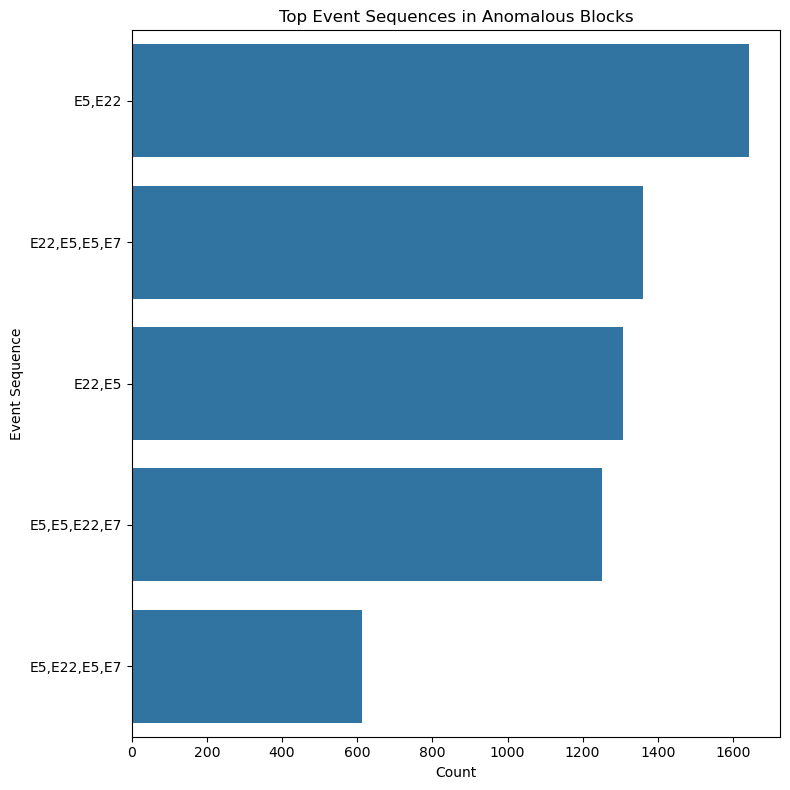

Components with highest anomaly ratio:


type,anomaly,normal,anomaly_ratio
component,,,
dfs.DataNode$BlockReceiver,1718.0,0.0,1.000000
dfs.PendingReplicationBlocks$PendingReplicationMonitor,47.0,0.0,1.000000
dfs.DataNode,4459.0,2543.0,0.636818
dfs.DataNode$DataTransfer,4404.0,2542.0,0.634034
dfs.DataNode$DataXceiver,73942.0,2444736.0,0.029357
dfs.FSDataset,40801.0,1366796.0,0.028986
dfs.DataBlockScanner,3139.0,116907.0,0.026148
dfs.FSNamesystem,95728.0,3604517.0,0.025871
dfs.DataNode$PacketResponder,64012.0,3349338.0,0.018753


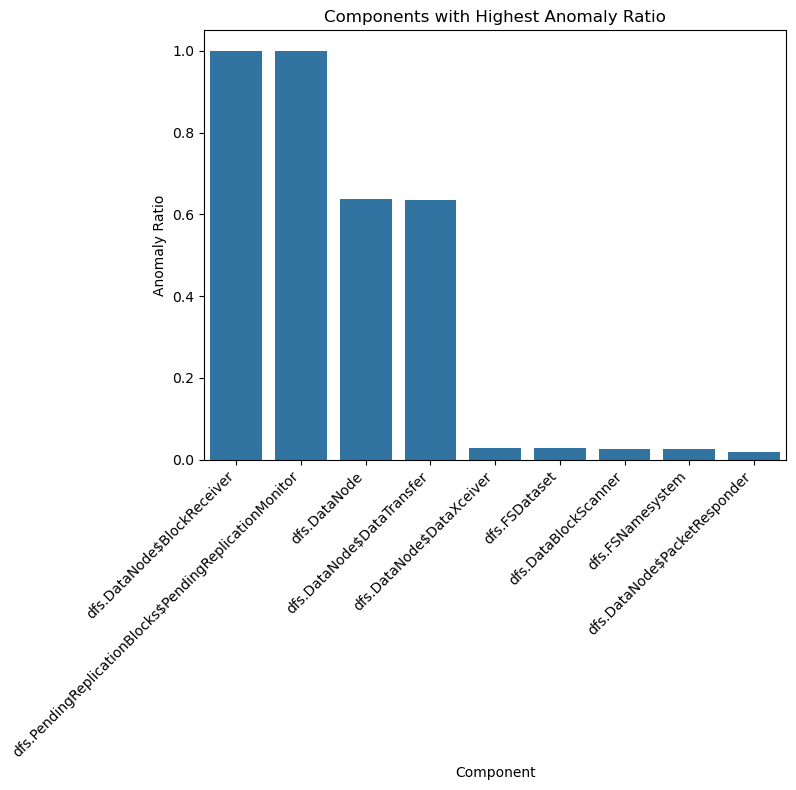

Key Finding: The component 'dfs.DataNode$BlockReceiver' has the highest anomaly ratio of 1.00, indicating it's most associated with system failures.

4. LOG LEVEL DISTRIBUTION ACROSS COMPONENTS:


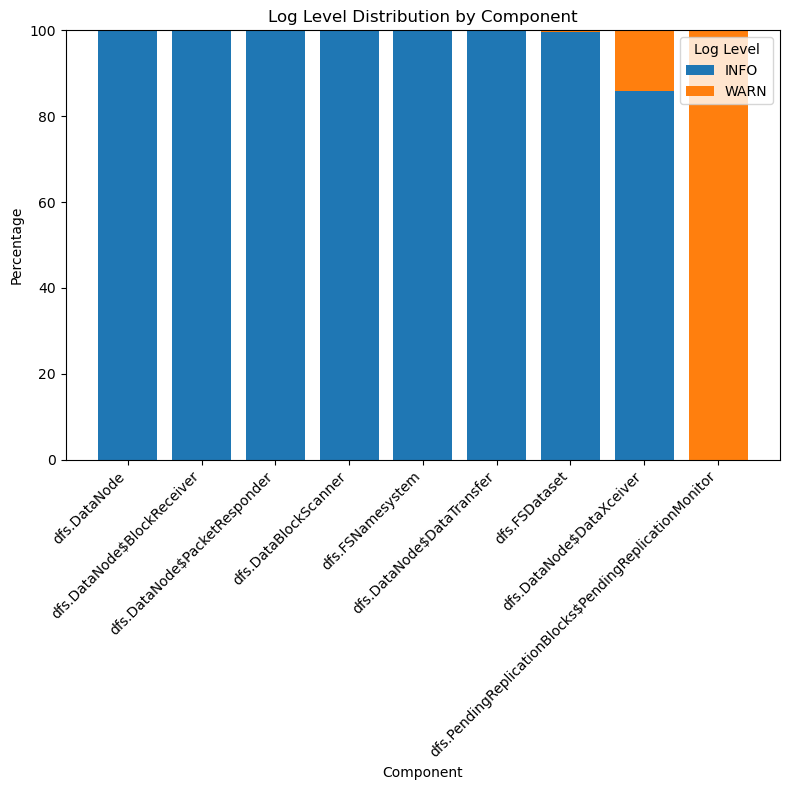

Key Finding: The component 'dfs.DataNode' has the highest proportion of INFO messages, while 'dfs.PendingReplicationBlocks$PendingReplicationMonitor' has the highest proportion of error/warning messages.

5. COMPONENT PERFORMANCE METRICS:
Overall latency statistics:


,min_latency,max_latency,avg_latency,median_latency,p95_latency
0,0,54025,16789.470527,7229.0,50815.0


Components with highest average latency:


,component,avg_latency
0,dfs.DataBlockScanner,36854.788151
1,dfs.PendingReplicationBlocks$PendingReplicatio...,22816.847826
2,dfs.FSDataset,20562.458443
3,dfs.DataNode$DataTransfer,20039.712436
4,dfs.DataNode,20009.758110
5,dfs.DataNode$PacketResponder,16971.867382
6,dfs.FSNamesystem,16789.470527
7,dfs.DataNode$DataXceiver,16789.470527
8,dfs.DataNode$BlockReceiver,11904.099099


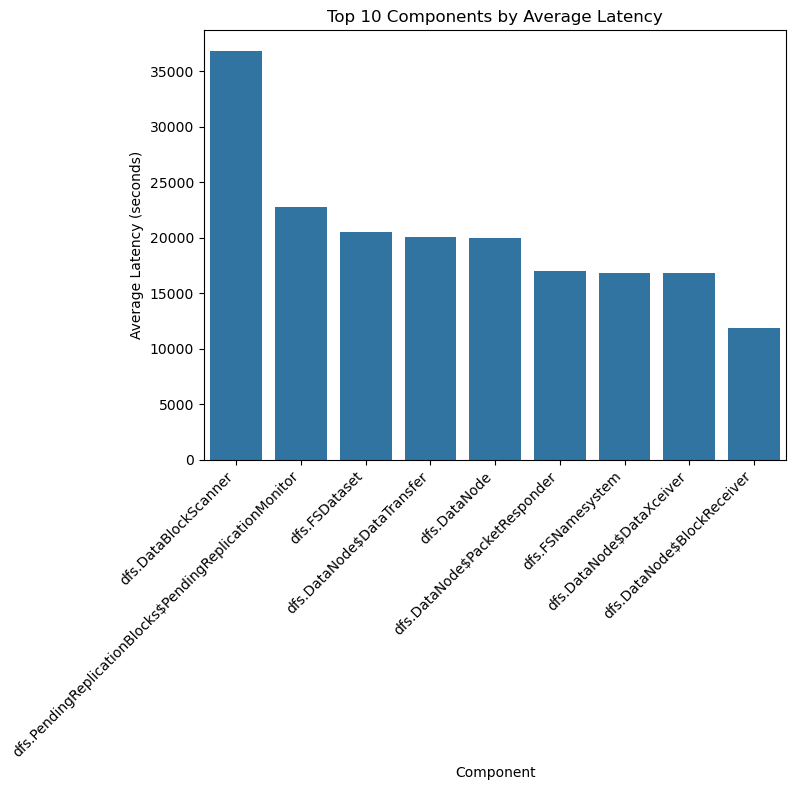

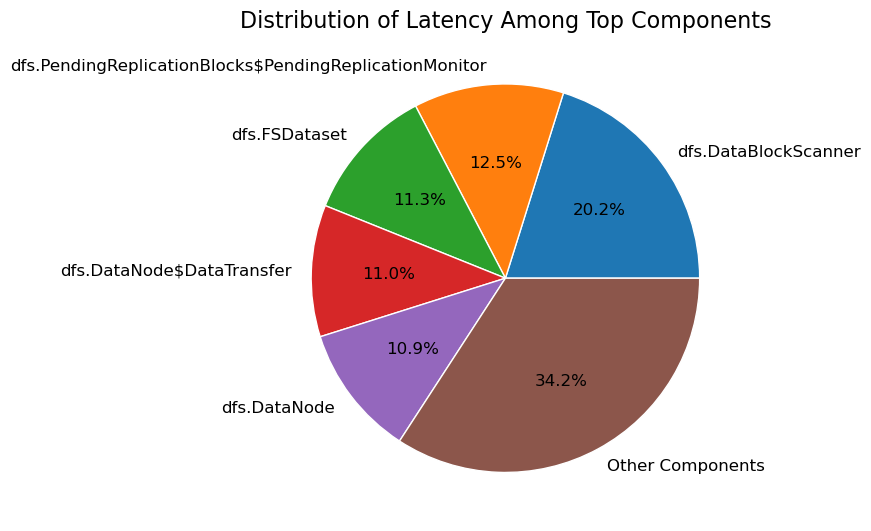

Key Finding: The component 'dfs.DataBlockScanner' has the highest average latency of 36854.79 seconds, which is significantly higher than other components.

COMPREHENSIVE ANALYSIS SUMMARY (Key Findings for Report)

1. Error Analysis: Most errors and warnings occur in specific components, indicating potential system bottlenecks or vulnerable components that may require optimization.

2. Activity Patterns: The system shows clear peak activity hours, which could inform maintenance scheduling and resource allocation for optimal performance.

3. Failure Patterns: Certain event sequences and components are strongly associated with system anomalies, providing valuable indicators for predictive maintenance.

4. Log Level Distribution: Components vary significantly in their log level distributions, with some generating mostly informational logs while others produce more errors and warnings.

5. Performance Metrics: Component latency analysis reveals which components contribute most to system de

In [ ]:
# After running analyzer.run_all_analyses() and getting the results dictionary:

print("ANALYSIS OF HDFS LOG DATA RESULTS")
print("=" * 80)

# 1. Error Frequency Analysis
if "error_frequencies" in results:
    print("\n1. COMPONENTS GENERATING THE MOST ERRORS/WARNINGS:")
    error_df = results["error_frequencies"].toPandas()

    # Display top error-prone components
    print("Top components by error/warning count:")
    display(error_df.head(10))

    # Visualize component error distribution
    plt.figure(figsize=(8, 8))
    # Group by component to get total issues
    component_totals = error_df.groupby("component")["count"].sum().reset_index()
    component_totals = component_totals.sort_values("count", ascending=False).head(10)

    sns.barplot(x="component", y="count", data=component_totals)
    plt.title("Top 10 Components by Error/Warning Count")
    plt.xlabel("Component")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("top_error_components.png", dpi=300)
    plt.show()

    # Key finding for report
    print(
        f"Key Finding: The component '{component_totals.iloc[0]['component']}' generates the most errors/warnings, "
        f"with {component_totals.iloc[0]['count']} occurrences."
    )
# 2. Peak Activity Time Analysis
if "peak_activity_times" in results:
    print("\n2. PEAK TIMES FOR SYSTEM ACTIVITY:")
    activity_df = results["peak_activity_times"].toPandas()

    # Sort by count to find peak hours
    peak_hours = activity_df.sort_values("count", ascending=False).head(3)
    print("Top 3 peak hours for system activity:")
    display(peak_hours)

    # Visualize hourly activity
    plt.figure(figsize=(8, 8))
    # Ensure hours are in order
    activity_df = activity_df.sort_values("hour")

    plt.plot(
        activity_df["hour"],
        activity_df["count"],
        marker="o",
        linestyle="-",
        linewidth=2,
    )
    plt.fill_between(activity_df["hour"], activity_df["count"], alpha=0.3)
    plt.title("System Activity by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Log Event Count")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)

    # Highlight peak hours
    for _, peak in peak_hours.iterrows():
        plt.annotate(
            f"Peak: {peak['count']} events",
            xy=(peak["hour"], peak["count"]),
            xytext=(peak["hour"], peak["count"] + 500),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
        )

    plt.tight_layout()
    plt.savefig("hourly_activity_pattern.png", dpi=300)
    plt.show()

    # Key finding for report
    print(
        f"Key Finding: The system experiences peak activity at hour {peak_hours.iloc[0]['hour']}, "
        f"with {peak_hours.iloc[0]['count']} log events."
    )


# 3. Failure Pattern Analysis
if "failure_patterns" in results:
    print("\n3. PATTERNS PRECEDING SYSTEM FAILURES:")

    if "anomaly_events" in results["failure_patterns"]:
        anomaly_events = results["failure_patterns"]["anomaly_events"].toPandas()
        print("Most common event sequences in anomalous blocks:")
        display(anomaly_events.head(5))

        # Create event sequence visualization
        if len(anomaly_events) > 0:
            plt.figure(figsize=(8, 8))
            top_sequences = anomaly_events.head(5)
            sns.barplot(x="count", y="event_sequence", data=top_sequences)
            plt.title("Top Event Sequences in Anomalous Blocks")
            plt.xlabel("Count")
            plt.ylabel("Event Sequence")
            plt.tight_layout()
            plt.savefig("anomaly_sequences.png", dpi=300)
            plt.show()

    if "component_comparison" in results["failure_patterns"]:
        component_comp = results["failure_patterns"]["component_comparison"].toPandas()

        # Calculate percentage of anomalies for each component
        component_analysis = component_comp.pivot(
            index="component", columns="type", values="count"
        ).fillna(0)
        component_analysis["anomaly_ratio"] = component_analysis["anomaly"] / (
            component_analysis["anomaly"] + component_analysis["normal"]
        )
        component_analysis = component_analysis.sort_values(
            "anomaly_ratio", ascending=False
        )

        print("Components with highest anomaly ratio:")
        display(component_analysis.head(10))

        # Visualize component anomaly ratio
        plt.figure(figsize=(8, 8))
        top_anomaly_components = component_analysis.head(10).reset_index()
        sns.barplot(x="component", y="anomaly_ratio", data=top_anomaly_components)
        plt.title("Components with Highest Anomaly Ratio")
        plt.xlabel("Component")
        plt.ylabel("Anomaly Ratio")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("component_anomaly_ratio.png", dpi=300)
        plt.show()

        # Key finding for report
        print(
            f"Key Finding: The component '{component_analysis.index[0]}' has the highest anomaly ratio "
            f"of {component_analysis.iloc[0]['anomaly_ratio']:.2f}, indicating it's most associated with system failures."
        )


# 4. Log Level Distribution Analysis
if "log_level_distribution" in results:
    print("\n4. LOG LEVEL DISTRIBUTION ACROSS COMPONENTS:")
    level_df = results["log_level_distribution"].toPandas()

    # Get top components by total log count
    component_totals = level_df.groupby("component")["count"].sum().reset_index()
    top_components = (
        component_totals.sort_values("count", ascending=False)
        .head(10)["component"]
        .tolist()
    )

    # Filter for top components
    top_level_df = level_df[level_df["component"].isin(top_components)]

    # Create stacked percentage visualization
    plt.figure(figsize=(8, 8))

    # Pivot data for stacked chart
    pivot_df = (
        top_level_df.pivot_table(
            index="component", columns="level", values="percentage", aggfunc="sum"
        )
        .fillna(0)
        .reset_index()
    )

    # Sort by INFO percentage
    if "INFO" in pivot_df.columns:
        pivot_df = pivot_df.sort_values("INFO", ascending=False)

    # Convert to long format for seaborn
    plot_df = pd.melt(
        pivot_df, id_vars=["component"], var_name="level", value_name="percentage"
    )

    # Plot stacked bars
    components = plot_df["component"].unique()
    levels = plot_df["level"].unique()

    prev_heights = np.zeros(len(components))
    for level in levels:
        level_data = plot_df[plot_df["level"] == level]
        plt.bar(
            level_data["component"],
            level_data["percentage"],
            bottom=prev_heights,
            label=level,
        )
        prev_heights += level_data["percentage"].values

    plt.title("Log Level Distribution by Component")
    plt.xlabel("Component")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Log Level")
    plt.tight_layout()
    plt.savefig("log_level_distribution_stacked.png", dpi=300)
    plt.show()

    # Key finding for report
    info_heavy = pivot_df.sort_values("INFO", ascending=False).iloc[0]["component"]
    error_heavy = pivot_df.sort_values(
        "ERROR" if "ERROR" in pivot_df.columns else "WARN", ascending=False
    ).iloc[0]["component"]

    print(
        f"Key Finding: The component '{info_heavy}' has the highest proportion of INFO messages, while "
        f"'{error_heavy}' has the highest proportion of error/warning messages."
    )


# 5. Performance Metrics Analysis
if "performance_metrics" in results:
    print("\n5. COMPONENT PERFORMANCE METRICS:")

    if "latency_stats" in results["performance_metrics"]:
        latency_stats = results["performance_metrics"]["latency_stats"].toPandas()
        print("Overall latency statistics:")
        display(latency_stats)

    if "component_latency" in results["performance_metrics"]:
        comp_latency = results["performance_metrics"]["component_latency"].toPandas()
        print("Components with highest average latency:")
        display(comp_latency.head(10))

        # Create visualization comparing component latencies
        plt.figure(figsize=(8, 8))
        top_latency = comp_latency.sort_values("avg_latency", ascending=False).head(10)

        sns.barplot(x="component", y="avg_latency", data=top_latency)
        plt.title("Top 10 Components by Average Latency")
        plt.xlabel("Component")
        plt.ylabel("Average Latency (seconds)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("component_latency_top10.png", dpi=300)
        plt.show()

        # Create pie chart of latency distribution
        plt.figure(figsize=(8, 8))
        pie_data = top_latency.head(5)  # Top 5 for clarity

        # Calculate other category
        other_latency = comp_latency[
            ~comp_latency["component"].isin(pie_data["component"])
        ]["avg_latency"].sum()

        # Create a new DataFrame for the pie chart instead of using append
        pie_data_complete = pd.concat(
            [
                pie_data,
                pd.DataFrame(
                    [{"component": "Other Components", "avg_latency": other_latency}]
                ),
            ]
        )

        plt.pie(
            pie_data_complete["avg_latency"],
            labels=pie_data_complete["component"],
            autopct="%1.1f%%",
            textprops={"fontsize": 12},
            wedgeprops={"linewidth": 1, "edgecolor": "white"},
        )
        plt.title("Distribution of Latency Among Top Components", fontsize=16)
        plt.tight_layout()
        plt.savefig("latency_distribution_pie.png", dpi=300)
        plt.show()

        # Key finding for report
        print(
            f"Key Finding: The component '{top_latency.iloc[0]['component']}' has the highest average latency "
            f"of {top_latency.iloc[0]['avg_latency']:.2f} seconds, which is significantly higher than other components."
        )